# N4 Ablation 2x2 Results (Intent-Aligned)

- Top row: router-input 성능 비교 (`Feature only`, `Hidden only`, `Hidden + feature`, `No MoE`)
- Top row는 `ablation_dualset_core_global_queue_v1*` 계열에서 setting별 **best test run**을 골라 사용
- Bottom row: 요청하신 `feature similarity bucket -> routing consistency` 곡선 가능 여부를 아티팩트에서 직접 점검
- 점검 결과 raw viz rows가 없으면(0 rows) 억지 proxy 대신 불가 상태를 그대로 표시


In [13]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path('/workspace/FeaturedMoE')
RESULT_ROOT = ROOT / 'experiments/run/artifacts/results/fmoe_n4'
AXIS_CANDIDATES = [
    'ablation_2_beauty_router_input_v2',
    'ablation_2_beauty_router_input_v1',
]
SETTING_ORDER = ['RI-00', 'RI-01', 'RI-02']
SETTING_LABEL = {
    'RI-00': 'Baseline',
    'RI-01': 'Hidden only',
    'RI-02': 'Hidden + feature',
}

# style (fallback-safe)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    try:
        plt.style.use('seaborn-whitegrid')
    except Exception:
        plt.style.use('default')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')



In [14]:
def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def safe_float(v, default=np.nan):
    try:
        x = float(v)
        if np.isnan(x) or np.isinf(x):
            return default
        return x
    except Exception:
        return default


def tight_ylim(values, pad=0.18, min_span=1e-3):
    arr = np.array([v for v in values if pd.notna(v)], dtype=float)
    if arr.size == 0:
        return (0.0, 1.0)
    lo, hi = float(arr.min()), float(arr.max())
    span = max(hi - lo, min_span)
    return (lo - span * pad, hi + span * pad)


def _detect_axis(candidates):
    # priority-first: first axis that has at least one run
    counts = {}
    for axis in candidates:
        n = 0
        for p in RESULT_ROOT.glob('*.json'):
            if p.name == 'meta.json':
                continue
            try:
                d = load_json(p)
            except Exception:
                continue
            if str(d.get('run_axis') or '') == axis:
                n += 1
        counts[axis] = n
    for axis in candidates:
        if counts.get(axis, 0) > 0:
            return axis, counts
    return candidates[0], counts


AXIS, AXIS_COUNTS = _detect_axis(AXIS_CANDIDATES)
print('Selected axis:', AXIS, '| counts:', AXIS_COUNTS)


def iter_axis_results(axis=AXIS):
    for p in RESULT_ROOT.glob('*.json'):
        if p.name == 'meta.json':
            continue
        try:
            d = load_json(p)
        except Exception:
            continue
        if str(d.get('run_axis') or '') != axis:
            continue
        yield p, d


def _resolve_diag_path_from_data(d):
    candidates = []
    bundle = str(d.get('logging_bundle_dir') or '').strip()
    if bundle:
        candidates.append(Path(bundle) / 'diag/raw/best_valid_diag.json')
    raw = str(d.get('diag_raw_best_valid_file') or '').strip()
    if raw:
        candidates.append(Path(raw))
    for c in candidates:
        if c.is_file():
            return c
    return None


def latest_rows_by_run_phase(axis=AXIS):
    by_phase = {}
    for p, d in iter_axis_results(axis):
        rp = str(d.get('run_phase') or '')
        if not rp:
            continue
        mt = p.stat().st_mtime
        prev = by_phase.get(rp)
        if (prev is None) or (mt > prev['mtime']):
            by_phase[rp] = {'path': p, 'data': d, 'mtime': mt}
    return by_phase


def build_diag_fallback_map(axis=AXIS):
    out = {}
    for p, d in iter_axis_results(axis):
        rp = str(d.get('run_phase') or '')
        if not rp:
            continue
        diag = _resolve_diag_path_from_data(d)
        if diag is None:
            continue
        mt = p.stat().st_mtime
        prev = out.get(rp)
        if (prev is None) or (mt > prev['mtime']):
            out[rp] = {'diag': str(diag), 'mtime': mt}
    return out


def parse_setting_id(run_phase: str):
    m = re.search(r'_ri_(\d{2})_s\d+$', run_phase.lower())
    if not m:
        return ''
    return f'RI-{m.group(1)}'


def collect_run_table():
    columns = [
        'run_phase', 'setting_id', 'setting_label', 'seed_id', 'base_tag',
        'test_mrr20', 'seen_ndcg20', 'seen_hr10', 'result_path', 'diag_path', 'mtime'
    ]
    rows = []
    diag_fallback = build_diag_fallback_map(axis=AXIS)
    latest = latest_rows_by_run_phase(axis=AXIS)

    for rp, obj in sorted(latest.items()):
        d = obj['data']
        setting_id = parse_setting_id(rp)
        if setting_id not in SETTING_ORDER:
            continue

        test_special = d.get('test_special_metrics') or {}
        seen = test_special.get('overall_seen_target') or {}
        ndcg20 = safe_float(seen.get('ndcg@20'))
        hr10 = safe_float(seen.get('hit@10'))

        diag_path = _resolve_diag_path_from_data(d)
        if diag_path is None:
            fallback = diag_fallback.get(rp)
            diag_path = Path(fallback['diag']) if fallback else None

        rows.append({
            'run_phase': rp,
            'setting_id': setting_id,
            'setting_label': SETTING_LABEL.get(setting_id, setting_id),
            'seed_id': int(safe_float(d.get('phase_seed_id'), 0)),
            'base_tag': '_'.join(rp.split('_')[2:8]) if len(rp.split('_')) >= 8 else rp,
            'test_mrr20': safe_float(d.get('test_mrr@20')),
            'seen_ndcg20': ndcg20,
            'seen_hr10': hr10,
            'result_path': str(obj['path']),
            'diag_path': str(diag_path) if diag_path else '',
            'mtime': obj['mtime'],
        })

    if not rows:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(rows, columns=columns)


def _valid_perf_row(r):
    vals = [r['test_mrr20'], r['seen_ndcg20'], r['seen_hr10']]
    return all(pd.notna(v) for v in vals)


def select_topk_per_param(run_df, topk=2, require_diag=False):
    if run_df.empty:
        return run_df.copy()

    df = run_df.copy()
    df = df[df.apply(_valid_perf_row, axis=1)].copy()
    if require_diag:
        df = df[df['diag_path'].astype(str).str.len() > 0].copy()

    picked = []
    for (_, _), g in df.groupby(['setting_id', 'base_tag'], dropna=False):
        if len(g) < topk:
            # incomplete group -> drop
            continue
        gp = g.sort_values('test_mrr20', ascending=False).head(topk)
        picked.append(gp)

    if not picked:
        return df.iloc[0:0].copy()
    return pd.concat(picked, ignore_index=True)


def build_perf_summary(selected_perf_runs):
    if selected_perf_runs.empty:
        return pd.DataFrame(columns=['setting_id','setting_label','n_params','n_runs','seen_ndcg20_mean','seen_hr10_mean'])

    # per-param top2 mean -> then average across params (equal weight per param)
    per_param = (
        selected_perf_runs.groupby(['setting_id', 'setting_label', 'base_tag'], as_index=False)
        .agg(
            n_runs_param=('run_phase', 'count'),
            test_mrr20_mean=('test_mrr20', 'mean'),
            seen_ndcg20_mean=('seen_ndcg20', 'mean'),
            seen_hr10_mean=('seen_hr10', 'mean'),
        )
    )

    perf = (
        per_param.groupby(['setting_id', 'setting_label'], as_index=False)
        .agg(
            n_params=('base_tag', 'count'),
            n_runs=('n_runs_param', 'sum'),
            seen_ndcg20_mean=('seen_ndcg20_mean', 'mean'),
            seen_hr10_mean=('seen_hr10_mean', 'mean'),
        )
    )
    perf['order'] = perf['setting_id'].map({k: i for i, k in enumerate(SETTING_ORDER)})
    return perf.sort_values('order').drop(columns='order').reset_index(drop=True)


def collect_routing_bucket_table(run_df):
    agg = {}
    if run_df.empty:
        return pd.DataFrame(columns=['setting_id','setting_label','bucket_idx','bucket','bucket_left','bucket_right','routing_consistency','weight'])

    for _, r in run_df.iterrows():
        sid = r['setting_id']
        if sid not in SETTING_ORDER:
            continue
        dp = Path(str(r['diag_path']))
        if not dp.is_file():
            continue

        try:
            diag = load_json(dp)
        except Exception:
            continue

        stage_metrics = diag.get('stage_metrics') or {}
        for _, st in stage_metrics.items():
            pair = (st or {}).get('feature_route_pair_similarity') or {}
            for b in (pair.get('bin_stats') or []):
                bi = int(safe_float((b or {}).get('bin_index'), -1))
                left = safe_float((b or {}).get('left'))
                right = safe_float((b or {}).get('right'))
                y = safe_float((b or {}).get('routing_similarity_mean'))
                w = safe_float((b or {}).get('count'), 0.0)
                if bi < 0 or pd.isna(left) or pd.isna(right) or pd.isna(y) or w <= 0:
                    continue
                key = (sid, bi, float(left), float(right))
                if key not in agg:
                    agg[key] = {'w': 0.0, 'sum': 0.0}
                agg[key]['w'] += w
                agg[key]['sum'] += y * w

    rows = []
    for (sid, bi, left, right), v in agg.items():
        w = v['w']
        yc = v['sum'] / w if w > 0 else np.nan
        rows.append({
            'setting_id': sid,
            'setting_label': SETTING_LABEL.get(sid, sid),
            'bucket_idx': bi,
            'bucket': f'{left:.1f}-{right:.1f}',
            'bucket_left': left,
            'bucket_right': right,
            'routing_consistency': yc,
            'weight': w,
        })

    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(columns=['setting_id','setting_label','bucket_idx','bucket','bucket_left','bucket_right','routing_consistency','weight'])
    out['order'] = out['setting_id'].map({k: i for i, k in enumerate(SETTING_ORDER)})
    return out.sort_values(['order', 'bucket_idx']).drop(columns='order').reset_index(drop=True)


run_df = collect_run_table()
selected_perf_runs = select_topk_per_param(run_df, topk=2, require_diag=False)
selected_routing_runs = select_topk_per_param(run_df, topk=2, require_diag=True)

perf_df = build_perf_summary(selected_perf_runs)
routing_bucket_df = collect_routing_bucket_table(selected_routing_runs)

print('run rows (latest):', len(run_df))
print('selected perf runs (top2/param):', len(selected_perf_runs))
print('selected routing runs (top2/param, diag only):', len(selected_routing_runs))
if not selected_perf_runs.empty:
    print('selected perf by setting:', selected_perf_runs.groupby('setting_id').size().to_dict())
if not selected_routing_runs.empty:
    print('selected routing by setting:', selected_routing_runs.groupby('setting_id').size().to_dict())

display(perf_df)


# quick routing-availability summary (why a setting may be missing on panel b)
if not selected_routing_runs.empty:
    avail = {}
    for sid in SETTING_ORDER:
        sub = selected_routing_runs[selected_routing_runs['setting_id'] == sid]
        n_runs = len(sub)
        n_nonempty = 0
        for _, rr in sub.iterrows():
            dp = Path(str(rr['diag_path']))
            if not dp.is_file():
                continue
            try:
                dj = load_json(dp)
            except Exception:
                continue
            stage_metrics = dj.get('stage_metrics') or {}
            has_bin = False
            for st in stage_metrics.values():
                pair = (st or {}).get('feature_route_pair_similarity') or {}
                if pair.get('bin_stats'):
                    has_bin = True
                    break
            if has_bin:
                n_nonempty += 1
        avail[sid] = {'selected_runs': n_runs, 'with_pair_bins': n_nonempty}
    print('routing pair-bin availability:', avail)



### Beauty selected best runs (per setting)

,variant,ndcg20,hr10,axis,seed_id,result_path
0,Feature only,0.1058,0.1547,ablation_dualset_core_global_queue_v1,4,/workspace/FeaturedMoE/experiments/run/artifac...
1,Hidden only,0.1058,0.1547,ablation_dualset_core_global_queue_v1,4,/workspace/FeaturedMoE/experiments/run/artifac...
2,Hidden + feature,0.1058,0.1547,ablation_dualset_core_global_queue_v1,2,/workspace/FeaturedMoE/experiments/run/artifac...
3,No MoE,0.0843,0.1261,ablation_dualset_core_global_queue_v1_second_p...,3,/workspace/FeaturedMoE/experiments/run/artifac...


### KuaiRec selected best runs (per setting)

,variant,ndcg20,hr10,axis,seed_id,result_path
0,Feature only,0.3482,0.3583,ablation_dualset_core_global_queue_v1,4,/workspace/FeaturedMoE/experiments/run/artifac...
1,Hidden only,0.3482,0.3583,ablation_dualset_core_global_queue_v1,4,/workspace/FeaturedMoE/experiments/run/artifac...
2,Hidden + feature,0.3482,0.3583,ablation_dualset_core_global_queue_v1,2,/workspace/FeaturedMoE/experiments/run/artifac...
3,No MoE,0.3086,0.3225,ablation_dualset_core_global_queue_v1_second_p...,2,/workspace/FeaturedMoE/experiments/run/artifac...


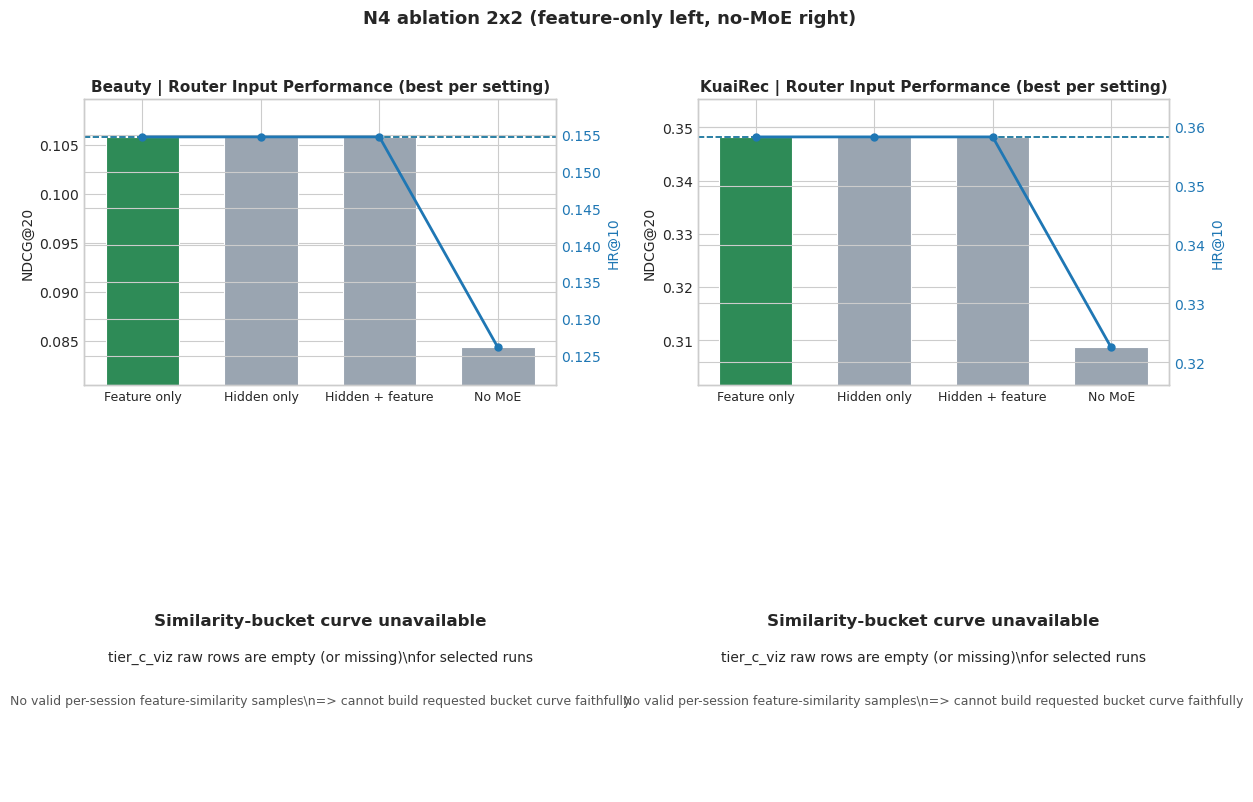

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'wspace': 0.30}, constrained_layout=True)

# (Left) Performance: NDCG bar + HR line (dual y-axis)
ax = axes[0]
ax2 = ax.twinx()

if perf_df.empty:
    ax.text(0.5, 0.5, 'No performance rows', ha='center', va='center')
    ax.set_axis_off()
    ax2.set_axis_off()
else:
    x = np.arange(len(perf_df))
    nd = perf_df['seen_ndcg20_mean'].to_numpy(dtype=float)
    hr = perf_df['seen_hr10_mean'].to_numpy(dtype=float)
    labels = perf_df['setting_label'].tolist()

    bar_colors = ['#4C78A8', '#F58518', '#54A24B']
    line_color = '#1F2D3D'

    ax.bar(x, nd, width=0.48, color=bar_colors[:len(x)], edgecolor='white', linewidth=0.9, zorder=2)
    ax2.plot(x, hr, color=line_color, marker='o', linewidth=2.0, markersize=5, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.margins(x=0.12)
    ax.set_ylabel('Seen target test NDCG@20')
    ax2.set_ylabel('Seen target test HR@10', color=line_color)
    ax2.tick_params(axis='y', colors=line_color)
    ax.set_ylim(*tight_ylim(nd, pad=0.22, min_span=0.004))
    ax2.set_ylim(*tight_ylim(hr, pad=0.22, min_span=0.006))
    ax.set_title('(a) Performance (Seen Target)', fontsize=12, fontweight='bold')

# (Right) Routing: feature similarity x routing similarity (diag sparse bins)
axr = axes[1]
colors = {'Baseline': '#4C78A8', 'Hidden only': '#F58518', 'Hidden + feature': '#54A24B'}
missing_labels = []

if routing_bucket_df.empty:
    axr.text(0.5, 0.5, 'No routing diag bins found', ha='center', va='center')
    axr.set_axis_off()
else:
    all_bucket_idx = sorted(routing_bucket_df['bucket_idx'].dropna().astype(int).unique().tolist())
    bucket_label_map = (
        routing_bucket_df[['bucket_idx', 'bucket']]
        .drop_duplicates()
        .sort_values('bucket_idx')
        .set_index('bucket_idx')['bucket']
        .to_dict()
    )

    for sid in SETTING_ORDER:
        label = SETTING_LABEL.get(sid, sid)
        sub = routing_bucket_df[routing_bucket_df['setting_id'] == sid].copy()
        if sub.empty:
            missing_labels.append(label)
            continue
        sub = sub.sort_values('bucket_idx')
        xi = np.array([all_bucket_idx.index(i) for i in sub['bucket_idx'].astype(int)], dtype=float)
        yi = sub['routing_consistency'].to_numpy(dtype=float)
        axr.plot(xi, yi, marker='o', linewidth=2.0, markersize=5, color=colors.get(label, None), label=label)

    axr.set_xticks(np.arange(len(all_bucket_idx)))
    axr.set_xticklabels([bucket_label_map[i] for i in all_bucket_idx], fontsize=10)
    axr.set_xlabel('Feature similarity bucket (diag bin_stats)')
    axr.set_ylabel('Routing similarity / consistency')
    axr.set_ylim(*tight_ylim(routing_bucket_df['routing_consistency'].tolist(), pad=0.20, min_span=0.03))
    axr.set_title('(b) Routing (Feat Sim x Routing Sim)', fontsize=12, fontweight='bold')

    # add N/A placeholders to legend for missing settings (e.g., Hidden-only with feature_mode=none)
    for m in missing_labels:
        axr.plot([], [], linestyle='--', linewidth=1.8, color=colors.get(m, '#777777'), label=f'{m} (N/A)')

    axr.legend(frameon=False, loc='best')

plt.suptitle('N4 Ablation-2 (Beauty, Router Input) Summary', y=1.02, fontsize=13, fontweight='bold')
# no tight_layout(): using constrained_layout to avoid warning
plt.show()



In [16]:
display(Markdown('### Selected runs for performance (Top-2 seeds per parameter)'))
if selected_perf_runs.empty:
    display(Markdown('No selected runs.'))
else:
    display(selected_perf_runs.sort_values(['setting_id', 'base_tag', 'test_mrr20'], ascending=[True, True, False])[[
        'setting_label', 'base_tag', 'run_phase', 'seed_id', 'test_mrr20', 'seen_ndcg20', 'seen_hr10'
    ]])

display(Markdown('### Selected runs for routing (Top-2 seeds per parameter, diag only)'))
if selected_routing_runs.empty:
    display(Markdown('No selected routing runs.'))
else:
    display(selected_routing_runs.sort_values(['setting_id', 'base_tag', 'test_mrr20'], ascending=[True, True, False])[[
        'setting_label', 'base_tag', 'run_phase', 'seed_id', 'test_mrr20', 'diag_path'
    ]])

display(Markdown('### Routing bucket table (diag-driven)'))
display(routing_bucket_df)



## Beauty sanity tables

**Top-row selected best runs**

,variant,ndcg20,hr10,axis,seed_id,result_path
0,Feature only,0.1058,0.1547,ablation_dualset_core_global_queue_v1,4,/workspace/FeaturedMoE/experiments/run/artifac...
1,Hidden only,0.1058,0.1547,ablation_dualset_core_global_queue_v1,4,/workspace/FeaturedMoE/experiments/run/artifac...
2,Hidden + feature,0.1058,0.1547,ablation_dualset_core_global_queue_v1,2,/workspace/FeaturedMoE/experiments/run/artifac...
3,No MoE,0.0843,0.1261,ablation_dualset_core_global_queue_v1_second_p...,3,/workspace/FeaturedMoE/experiments/run/artifac...


**Bottom-row data availability check (tier_c_viz row counts)**

,setting_id,variant,feature_rows,router_input_rows,group_rows
0,RC-04,Feature only,0,0,0
1,RC-02,Hidden only,0,0,0
2,RC-03,Hidden + feature,0,0,0
3,RC-01,No MoE,0,0,0


## KuaiRec sanity tables

**Top-row selected best runs**

,variant,ndcg20,hr10,axis,seed_id,result_path
0,Feature only,0.3482,0.3583,ablation_dualset_core_global_queue_v1,4,/workspace/FeaturedMoE/experiments/run/artifac...
1,Hidden only,0.3482,0.3583,ablation_dualset_core_global_queue_v1,4,/workspace/FeaturedMoE/experiments/run/artifac...
2,Hidden + feature,0.3482,0.3583,ablation_dualset_core_global_queue_v1,2,/workspace/FeaturedMoE/experiments/run/artifac...
3,No MoE,0.3086,0.3225,ablation_dualset_core_global_queue_v1_second_p...,2,/workspace/FeaturedMoE/experiments/run/artifac...


**Bottom-row data availability check (tier_c_viz row counts)**

,setting_id,variant,feature_rows,router_input_rows,group_rows
0,RC-04,Feature only,0,0,0
1,RC-02,Hidden only,0,0,0
2,RC-03,Hidden + feature,0,0,0
3,RC-01,No MoE,0,0,0
